# Prediksi Data Penjualan Crumb & Bloom Bakery
Notebook ini bertujuan untuk melakukan analisis dan prediksi data penjualan berdasarkan file Excel yang tersedia.

Mean Squared Error: 1,579,033,141.45
R^2 Score: 0.9716


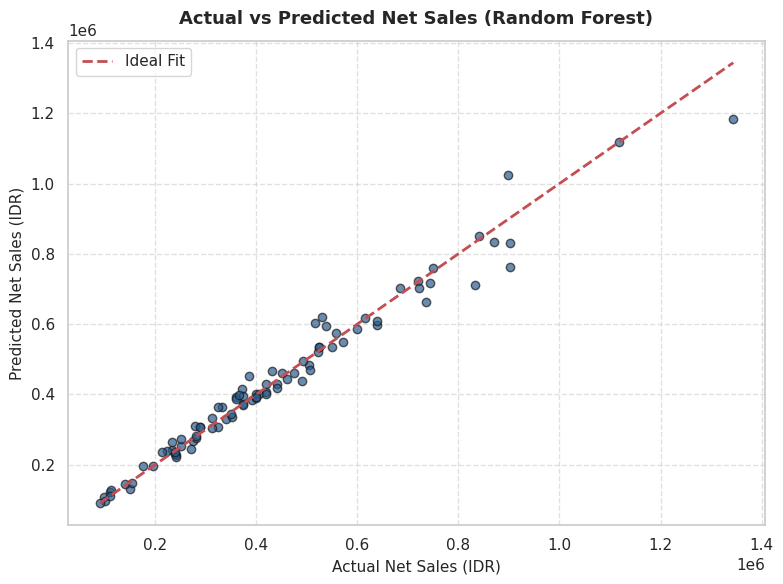

In [ ]:
# @title Default title text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set style visualisasi
sns.set_theme(style='whitegrid')

# Memuat data
file_path = 'crumb_bloom_bakery_sales_30_days (1).xlsx'
df = pd.read_excel(file_path, sheet_name='Sales_Data')

# Preprocessing sederhana
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week_encoded'] = df['date'].dt.dayofweek

# Memilih fitur dan target
features = ['month', 'day', 'day_of_week_encoded', 'unit_price', 'temperature', 'stock_remaining', 'customer_count']
target = 'net_sales'

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melatih model Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediksi dan Evaluasi
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:,.2f}')
print(f'R^2 Score: {r2:.4f}')

# --- TAMBAHAN KODE VISUALISASI ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='#2b5c8f', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Actual vs Predicted Net Sales (Random Forest)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Actual Net Sales (IDR)', fontsize=11)
plt.ylabel('Predicted Net Sales (IDR)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
!pip install gradio -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import gradio as gr

# 1. Load Data & Training Model
file_path = 'crumb_bloom_bakery_sales_30_days (1).xlsx'
df = pd.read_excel(file_path, sheet_name='Sales_Data')

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week_encoded'] = df['date'].dt.dayofweek

features = ['month', 'day', 'day_of_week_encoded', 'unit_price', 'temperature', 'stock_remaining', 'customer_count']
target = 'net_sales'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- FUNGSI TAB 1: DATA EXPLORER & FILTER ---
def filter_and_visualize(category, sales_channel, weather):
    filtered_df = df.copy()
    if category != "All":
        filtered_df = filtered_df[filtered_df['category'] == category]
    if sales_channel != "All":
        filtered_df = filtered_df[filtered_df['sales_channel'] == sales_channel]
    if weather != "All":
        filtered_df = filtered_df[filtered_df['weather'] == weather]

    total_rev = f"Rp {filtered_df['net_sales'].sum():,.2f}"
    total_qty = f"{filtered_df['quantity_sold'].sum():,}"
    avg_cust = f"{filtered_df['customer_count'].mean():.1f} orang"

    # Grafik Top Produk Berdasarkan Filter
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.set_theme(style='whitegrid')
    if not filtered_df.empty:
        top_prod = filtered_df.groupby('product')['net_sales'].sum().sort_values(ascending=True).tail(5)
        ax.barh(top_prod.index, top_prod.values / 1e6, color='#2b5c8f')
        ax.set_title(f'Top 5 Produk (Kategori: {category}, Kanal: {sales_channel})', fontsize=12, fontweight='bold')
        ax.set_xlabel('Net Sales (Juta IDR)')
    else:
        ax.text(0.5, 0.5, 'Tidak ada data untuk filter ini', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    plt.tight_layout()

    return total_rev, total_qty, avg_cust, fig

# --- FUNGSI TAB 2: ML PREDICTOR DENGAN PRESET ---
def predict_revenue(unit_price, temperature, stock_remaining, customer_count, is_weekend, promotion):
    dow_encoded = 5 if is_weekend == "Weekend (Sabtu/Minggu)" else 2 # Default Rabu untuk weekday
    input_data = pd.DataFrame([[7, 15, dow_encoded, unit_price, temperature, stock_remaining, customer_count]], columns=features)

    prediction = model.predict(input_data)[0]
    formatted_pred = f"Rp {prediction:,.2f}"

    # Grafik Feature Importance
    fig, ax = plt.subplots(figsize=(8, 4))
    importances = model.feature_importances_
    importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=True)
    ax.barh(importance_df['Feature'], importance_df['Importance'], color='#d97706')
    ax.set_title('Faktor Penentu Utama Model (Feature Importance)', fontsize=12, fontweight='bold')
    plt.tight_layout()

    return formatted_pred, fig

# --- MEMBANGUN ANTARMUKA MULTI-TAB GRADIO ---
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🥐 Crumb & Bloom Bakery - Interactive Intelligence Hub")
    gr.Markdown("Eksplorasi data historis toko atau lakukan simulasi prediksi penjualan menggunakan Machine Learning.")

    with gr.Tabs():
        # TAB 1: DATA EXPLORER
        with gr.TabItem("📊 Eksplorasi Data & Filter"):
            gr.Markdown("### Saring data transaksi berdasarkan kategori, kanal, atau cuaca.")
            with gr.Row():
                cat_dropdown = gr.Dropdown(choices=["All", "Pastry", "Bread", "Cake", "Coffee", "Non-Coffee"], value="All", label="Kategori Produk")
                channel_dropdown = gr.Dropdown(choices=["All", "In-Store", "GoFood", "GrabFood", "ShopeeFood"], value="All", label="Kanal Penjualan")
                weather_dropdown = gr.Dropdown(choices=["All", "Sunny", "Cloudy", "Rainy"], value="All", label="Kondisi Cuaca")

            with gr.Row():
                out_rev = gr.Textbox(label="Total Pendapatan (Net Sales)")
                out_qty = gr.Textbox(label="Total Kuantitas Terjual")
                out_cust = gr.Textbox(label="Rata-rata Pelanggan Harian")

            plot_filter = gr.Plot(label="Grafik Performa Produk")

            btn_filter = gr.Button("Terapkan Filter", variant="primary")
            btn_filter.click(fn=filter_and_visualize, inputs=[cat_dropdown, channel_dropdown, weather_dropdown], outputs=[out_rev, out_qty, out_cust, plot_filter])

        # TAB 2: ML PREDICTOR SIMULATOR
        with gr.TabItem("🤖 Simulator Prediksi Pendapatan (ML)"):
            gr.Markdown("### Uji skenario variabel operasional untuk memprediksi pendapatan.")
            with gr.Row():
                with gr.Column():
                    in_price = gr.Slider(minimum=15000, maximum=60000, step=1000, value=28000, label="Harga Satuan (Unit Price IDR)")
                    in_temp = gr.Slider(minimum=20, maximum=35, step=1, value=28, label="Suhu (°C)")
                    in_stock = gr.Slider(minimum=0, maximum=100, step=1, value=75, label="Sisa Stok")
                with gr.Column():
                    in_cust = gr.Slider(minimum=20, maximum=150, step=1, value=80, label="Jumlah Pelanggan")
                    in_weekend = gr.Radio(choices=["Weekday (Senin-Jumat)", "Weekend (Sabtu/Minggu)"], value="Weekday (Senin-Jumat)", label="Tipe Hari")
                    in_promo = gr.Dropdown(choices=["None", "Weekend Promo", "Buy 2 Get 1", "Coffee Combo", "Pastry Discount"], value="None", label="Promosi Aktif")

            out_pred = gr.Textbox(label="Estimasi Pendapatan Bersih (Net Sales)")
            plot_ml = gr.Plot(label="Analisis Kontribusi Fitur Model")

            btn_pred = gr.Button("Hitung Prediksi", variant="primary")
            btn_pred.click(fn=predict_revenue, inputs=[in_price, in_temp, in_stock, in_cust, in_weekend, in_promo], outputs=[out_pred, plot_ml])

# Menjalankan aplikasi
demo.launch(inline=True, share=True)

/tmp/ipykernel_1636/3931630425.py:77: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7c6a5b235f6e452e18.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.listdir('/content/drive/MyDrive')

['Prediksi Data Penjualan Crumb & Bloom Bakery',
 'IMG20220213142559.jpg',
 'IMG_20220216_194925.jpg',
 'IMG_20220216_195056.jpg',
 'IMG_20220216_195156.jpg',
 'IMG_20220216_194943.jpg',
 'IMG_20220216_194956.jpg',
 'IMG_20220216_195136.jpg',
 'IMG_20220216_195207.jpg',
 'IMG_20220216_195015.jpg',
 'IMG_20220216_195027.jpg',
 'IMG_20220216_195114.jpg',
 'IMG_20220217_094941.jpg',
 'IMG20220218084618.jpg',
 'IMG20220218084809.jpg',
 'IMG20220218084653.jpg',
 'IMG20220218084740.jpg',
 'IMG20220218084558.jpg',
 'IMG20220218084549.jpg',
 'IMG20220218084604.jpg',
 'IMG20220218084802.jpg',
 'IMG20220218084735.jpg',
 'IMG20220218084645.jpg',
 'IMG20220218084613.jpg',
 'IMG20220218084640.jpg',
 'IMG20220218084613_01.jpg',
 'IMG20220218084732.jpg',
 'IMG20220218084803.jpg',
 'IMG20220218084524.jpg',
 'IMG20220218084615.jpg',
 'IMG20220218084633.jpg',
 'IMG20220218084554.jpg',
 'IMG20220218084805.jpg',
 'IMG20220218084528.jpg',
 'IMG20220218084606.jpg',
 'IMG20220218084607.jpg',
 'IMG20220218084

In [4]:
os.listdir('/content/drive/MyDrive/Prediksi Data Penjualan Crumb & Bloom Bakery')

['prediksi_penjualan_bakery.ipynb',
 'crumb_bloom_bakery_sales_30_days (1).xlsx']

In [5]:
!git clone https://github.com/MangoLim3/BakerySalesDemo.git

Cloning into 'BakerySalesDemo'...


In [6]:
!cp -r "/content/drive/MyDrive/Prediksi Data Penjualan Crumb & Bloom Bakery/." "/content/BakerySalesDemo/"

In [7]:
!ls "/content/BakerySalesDemo"

'crumb_bloom_bakery_sales_30_days (1).xlsx'   prediksi_penjualan_bakery.ipynb


In [9]:
!cp -r "/content/drive/MyDrive/Prediksi Data Penjualan Crumb & Bloom Bakery/." "/content/BakerySalesDemo/"

In [10]:
%cd /content/BakerySalesDemo
!git add .
!git commit -m "Add project files"
!git push origin main

/content/BakerySalesDemo
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@242bb661591e.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/MangoLim3/BakerySalesDemo.git'


In [11]:
!git config --global user.name "MangoLim3"
!git config --global user.email "myreynano@gmail.com"

In [12]:
%cd /content/BakerySalesDemo

/content/BakerySalesDemo


In [13]:
!git status

On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   crumb_bloom_bakery_sales_30_days (1).xlsx
	new file:   prediksi_penjualan_bakery.ipynb



In [14]:
!git add .
!git commit -m "Add project files"

[main (root-commit) 964c19f] Add project files
 2 files changed, 1 insertion(+)
 create mode 100644 crumb_bloom_bakery_sales_30_days (1).xlsx
 create mode 100644 prediksi_penjualan_bakery.ipynb


In [15]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address
